In [2]:
import pandas as pd
import json

with open("balanced_flight_telemetry.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)
print(df.head())

              timestamp flight_info.callsign  flight_info.airframe_hours  \
0  2026-04-09T10:00:00Z           VIT-AI-400                14250.500000   
1  2026-04-09T10:00:01Z           VIT-AI-400                14250.500278   
2  2026-04-09T10:00:02Z           VIT-AI-400                14250.500556   
3  2026-04-09T10:00:03Z           VIT-AI-400                14250.500833   
4  2026-04-09T10:00:04Z           VIT-AI-400                14250.501111   

  flight_info.flight_phase  kinematics.altitude_ft  kinematics.airspeed_knots  \
0                  TAKEOFF                     0.0                     280.52   
1                  TAKEOFF                     0.0                     282.23   
2                  TAKEOFF                     0.0                     278.10   
3                  TAKEOFF                     0.0                     279.41   
4                  TAKEOFF                     0.0                     281.05   

   kinematics.g_force_axial  propulsion_sys.engine_1_egt

C:\Users\shibu\AppData\Local\Temp\ipykernel_10456\1222275819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='analytics_meta.maintenance_flag', data=df, ax=axes[0], palette='viridis')


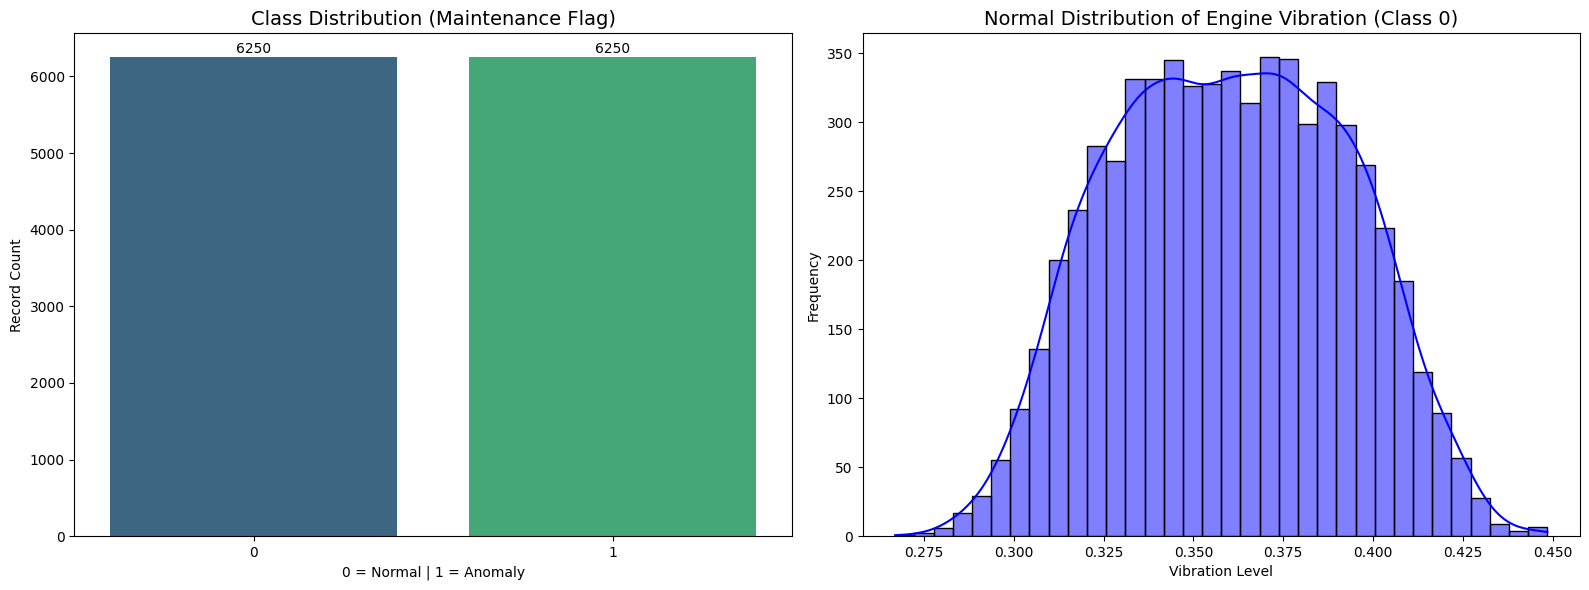

--- Data Summary ---
Total Vehicles: 5
Class Counts:
analytics_meta.maintenance_flag
0    6250
1    6250
Name: count, dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# 1. Load the data
with open('balanced_flight_telemetry.json', 'r') as f:
    data = json.load(f)

# 2. Flatten JSON into a DataFrame
df = pd.json_normalize(data)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPH 1: Class Distribution (Bar Chart) ---
sns.countplot(x='analytics_meta.maintenance_flag', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution (Maintenance Flag)', fontsize=14)
axes[0].set_xlabel('0 = Normal | 1 = Anomaly')
axes[0].set_ylabel('Record Count')

# Add text labels on the bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))

# --- GRAPH 2: Normal Distribution (Sensor Bell Curves) ---
# We plot the vibration distribution for the "Normal" state (flag 0) 
# to see the clean Gaussian curve before the anomaly drift begins.
normal_data = df[df['analytics_meta.maintenance_flag'] == 0]

sns.histplot(normal_data['propulsion_sys.engine_1_vibration'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('Normal Distribution of Engine Vibration (Class 0)', fontsize=14)
axes[1].set_xlabel('Vibration Level')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print Summary
print("--- Data Summary ---")
print(f"Total Vehicles: {df['flight_info.callsign'].nunique()}")
print(f"Class Counts:\n{df['analytics_meta.maintenance_flag'].value_counts()}")